# Chapter 10: Machine Learning Intro 2

In [1]:
import matplotlib.image as img
import matplotlib.pyplot as plt

import copy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from os import listdir
import seaborn as sns; sns.set()
from sklearn import metrics

## 10.1 Introduction

Now that we have seen the basics of Machine Learning, we know most of the do's and don'ts. We know what is required for a model, and how to aim our dataset to best suit it.

However, sometimes this is not enough. Sometimes we do all the theoretical cleaning and transform the data perfectly, but it still isn't ideal. Today we will be expanding on our existing knowledge of Machine Learning models to see what other methods we can use to improve the data more than just the basic transformations. 🤔

## 10.2 Flowers, again

First of all, let's see what we are working with. Today we will be exploring a different flower dataset, this one being filled with actual pictures! Let's load one in and see how we can display it.

In [2]:
flower = img.imread("flowers_data/flower training/0003.png")

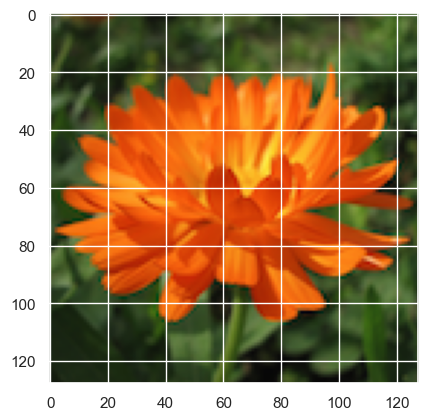

In [3]:
plt.imshow(flower)

Wonderful! Of course, this is not data as we are used to it. So let's have a look at the actual contents of the flower image.

In [4]:
flower

array([[[0.25490198, 0.3254902 , 0.1882353 , 1.        ],
        [0.28235295, 0.34117648, 0.22745098, 1.        ],
        [0.2901961 , 0.3529412 , 0.24313726, 1.        ],
        ...,
        [0.25882354, 0.37254903, 0.18039216, 1.        ],
        [0.28235295, 0.4       , 0.20392157, 1.        ],
        [0.2901961 , 0.41960785, 0.20392157, 1.        ]],

       [[0.20392157, 0.2784314 , 0.14901961, 1.        ],
        [0.23921569, 0.3019608 , 0.2       , 1.        ],
        [0.28627452, 0.34117648, 0.23921569, 1.        ],
        ...,
        [0.27058825, 0.36862746, 0.1764706 , 1.        ],
        [0.25490198, 0.37254903, 0.1764706 , 1.        ],
        [0.2509804 , 0.37254903, 0.17254902, 1.        ]],

       [[0.18431373, 0.2509804 , 0.13333334, 1.        ],
        [0.2627451 , 0.30980393, 0.20784314, 1.        ],
        [0.30980393, 0.3529412 , 0.24705882, 1.        ],
        ...,
        [0.2901961 , 0.37254903, 0.18431373, 1.        ],
        [0.24313726, 0.337254

### Question 1: How is our data object structured? Why is this the case? What do all these individual numbers mean?

*Hint: It might be intersting to determine the exact size of the data object.*

In [5]:
flower.shape

(128, 128, 4)

Our data object is displayed as a three-dimensional array. The first two dimensions have a length of 128, while the third one has a dimension of 4. When thinking about visual representations, a series of four numbers are quite common, especially when the last number is consistently 1. This is a common way to represent RGBA colors: think of each pixel as having red, green, blue, and alpha (transparency) values.

### Question 2: If you know what the numbers mean, can you extract each individual layer of the image (so four in total) and plot it so each layer is shown to their full potential?

let's start by extracting each layer.

In [6]:
layer1 = flower[:,:,0]
layer2 = flower[:,:,1]
layer3 = flower[:,:,2]
layer4 = flower[:,:,3]

If we follow the RGBA pattern, layer one should be all the red values.

In [7]:
layer1

array([[0.25490198, 0.28235295, 0.2901961 , ..., 0.25882354, 0.28235295,
        0.2901961 ],
       [0.20392157, 0.23921569, 0.28627452, ..., 0.27058825, 0.25490198,
        0.2509804 ],
       [0.18431373, 0.2627451 , 0.30980393, ..., 0.2901961 , 0.24313726,
        0.21568628],
       ...,
       [0.07843138, 0.07450981, 0.07843138, ..., 0.18431373, 0.20784314,
        0.22352941],
       [0.07843138, 0.07450981, 0.07058824, ..., 0.2       , 0.21568628,
        0.23529412],
       [0.07843138, 0.07450981, 0.07450981, ..., 0.20392157, 0.21960784,
        0.22745098]], dtype=float32)

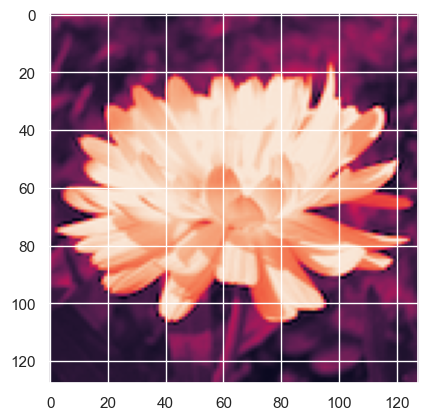

In [8]:
plt.imshow(layer1)

Interesting! The flower appears yellow because we're only passing one color channel without context. The system is interpreting this single value as if all colors are present. We can fix this by setting the other layers to zero, effectively filtering to show only the red channel.

In [9]:
flower[:,:,1] = np.zeros((128, 128))
flower[:,:,2] = np.zeros((128, 128))

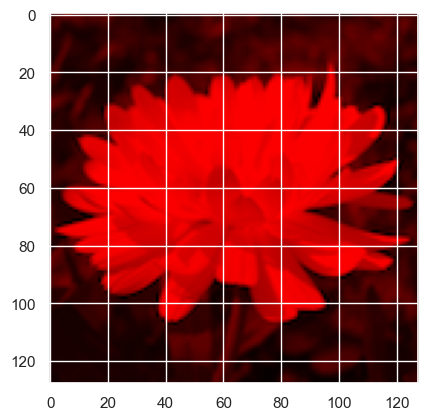

In [10]:
plt.imshow(flower)

## 10.3 Data Preperation

We want to train our model on all of our flowers, so we need to load them all into memory.

### 10.3.1 Making the data matrix

First, let's have a look at what files we have here.

In [11]:
training_files = listdir("flowers_data/flower training")
training_files

['0003.png',
 '0039.png',
 '0045.png',
 '0050.png',
 '0074.png',
 '0081.png',
 '0087.png',
 '0092.png',
 '0094.png',
 '0101.png',
 '0102.png',
 '0113.png',
 '0132.png',
 '0139.png',
 '0145.png',
 '0157.png',
 '0166.png',
 '0177.png',
 '0193.png',
 '0210.png']

### Question 3: Loading in all 128 * 128 * 4 datapoints for each flower would be too much. How could we solve this?

We can solve this with some clever data engineering! When reducing our dataset, we always lose some information, but depending on the method we choose, we can keep the most valuable parts. Some possible approaches include:

- Taking the mean of each colour value per flower
- Taking the total of each colour value per flower
- Taking the mean values of each row
- ...

### Question 4: Create a dataframe containing the reduced values of the flower dataset according to a method of your choice.

*Hint: if you can't decide on a method, pick the mean value of each colour.*

In [12]:
RGB_results = []

for file in training_files:
    flower_filepath = "flowers_data/flower training/" + file
    print("processing " + flower_filepath)
    
    bloem = img.imread(flower_filepath)
    
    RED_layer = bloem[:,:,0].mean()
    GREEN_layer = bloem[:,:,1].mean()
    BLUE_layer = bloem[:,:,2].mean()

    RGB_loop = np.array([RED_layer, GREEN_layer, BLUE_layer]).flatten()
    
    RGB_results.append(RGB_loop)

RGB_results =  pd.DataFrame(RGB_results)


processing flowers_data/flower training/0003.png
processing flowers_data/flower training/0039.png
processing flowers_data/flower training/0045.png
processing flowers_data/flower training/0050.png
processing flowers_data/flower training/0074.png
processing flowers_data/flower training/0081.png
processing flowers_data/flower training/0087.png
processing flowers_data/flower training/0092.png
processing flowers_data/flower training/0094.png
processing flowers_data/flower training/0101.png
processing flowers_data/flower training/0102.png
processing flowers_data/flower training/0113.png
processing flowers_data/flower training/0132.png
processing flowers_data/flower training/0139.png
processing flowers_data/flower training/0145.png
processing flowers_data/flower training/0157.png
processing flowers_data/flower training/0166.png
processing flowers_data/flower training/0177.png
processing flowers_data/flower training/0193.png
processing flowers_data/flower training/0210.png


In [13]:
RGB_results

,0,1,2
0,0.497575,0.316957,0.102415
1,0.536512,0.405759,0.149415
2,0.563964,0.173745,0.194148
3,0.483603,0.259570,0.217671
4,0.492960,0.476488,0.370090
5,0.656725,0.370400,0.338724
6,0.461579,0.330868,0.112952
7,0.557326,0.567570,0.396202
8,0.515288,0.296197,0.082329
9,0.515826,0.357648,0.270055


### 10.3.2 Building the outcome vector

Now that we have our X variables (the features), it is time to build our Y variable (the target). This will be the label representing the actual flower name. Read in the labels CSV file.

In [14]:
# Note: sep=";" tells pandas that semicolons separate columns in this CSV file
flower_metadata = pd.read_csv("flowers_data/all_flower_labels.csv", header = 0, sep = ";")
flower_metadata.head()

,file,label,name
0,0003.png,2,calendula
1,0006.png,1,rose
2,0016.png,1,rose
3,0021.png,2,calendula
4,0027.png,2,calendula


### Question 5: Examine the dataset above. Can we use this directly and merge it with our X dataset? Why or why not? Merge it!

In [15]:
RGB_results.shape

(20, 3)

In [16]:
flower_metadata.shape

(39, 3)

We have almost twice as many flowers in the labels dataset as in the original dataset. We cannot merge them directly; instead, we must only keep the labels for flowers we actually have data for.

In [17]:
outcome_vector = pd.DataFrame({"training_file" : training_files})
outcome_data = pd.merge(outcome_vector, flower_metadata, left_on = 'training_file', right_on = 'file')[["training_file","name" ]]
outcome_data.head()

,training_file,name
0,0003.png,calendula
1,0039.png,calendula
2,0045.png,rose
3,0050.png,rose
4,0074.png,rose


In [18]:
outcome_data.shape

(20, 2)

In [19]:
final_df = RGB_results.join(outcome_data)
final_df

,0,1,2,training_file,name
0,0.497575,0.316957,0.102415,0003.png,calendula
1,0.536512,0.405759,0.149415,0039.png,calendula
2,0.563964,0.173745,0.194148,0045.png,rose
3,0.483603,0.259570,0.217671,0050.png,rose
4,0.492960,0.476488,0.370090,0074.png,rose
5,0.656725,0.370400,0.338724,0081.png,rose
6,0.461579,0.330868,0.112952,0087.png,calendula
7,0.557326,0.567570,0.396202,0092.png,rose
8,0.515288,0.296197,0.082329,0094.png,calendula
9,0.515826,0.357648,0.270055,0101.png,rose


### 10.3.3 Exploring our training data

Before we build our model, let's explore the data we have. It's important to understand what flowers are in our dataset and how many examples of each we have.

In [30]:
final_df['name'].value_counts()

name
calendula    10
rose         10
Name: count, dtype: int64

Perfect! We can see that our dataset contains two flower types (calendula and rose) with a relatively balanced number of examples for each. This is good for training a fair model, as both classes have similar representation.

## 10.4 Building the model

Now that we have our data matrix, we are going to build a model. In python this is done by first defining a model and storing this in an object. Afterwards we add data to this model and train it.

In [20]:
ML_model = RandomForestClassifier()

In [21]:
ML_model.fit(final_df[[0, 1, 2]], final_df['name'])

RandomForestClassifier()

## 10.5 Evaluating the model on the training data

A first step we can do to see if our model has at least trained itself is to give it the training data to predict. If it has learned something, we expect it to predict these labels quite well.

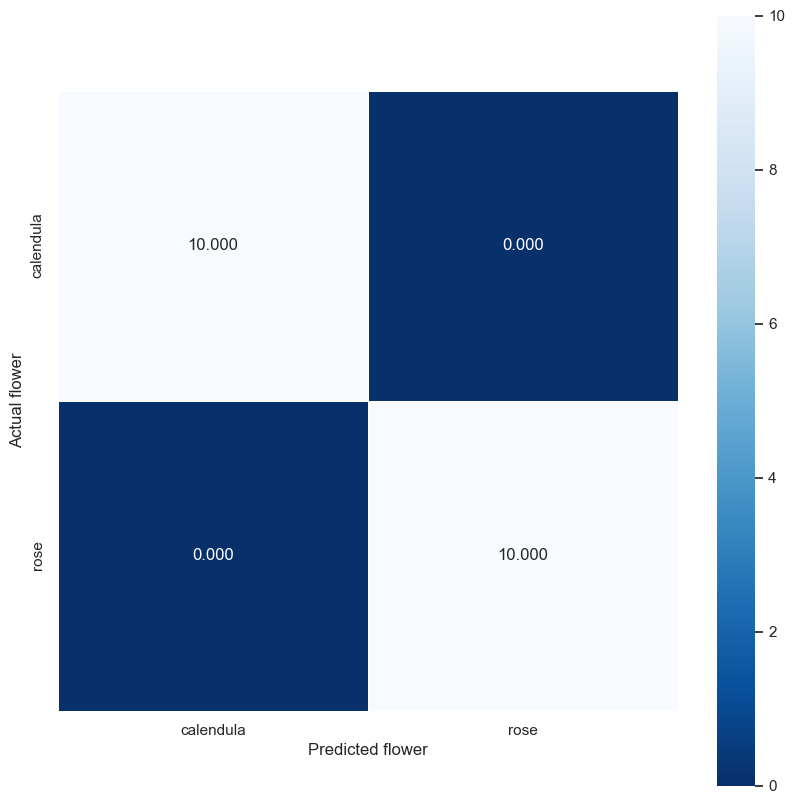

In [22]:
# A confusion matrix shows how often our model is correct and what mistakes it makes
# Diagonal values (top-left to bottom-right) are correct predictions
# Off-diagonal values are mistakes
y_pred = ML_model.predict(final_df[[0, 1, 2]])

labels = ['calendula', 'rose']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(final_df['name'], y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual flower');
plt.xlabel('Predicted flower');

### Question 6: Interpret the confusion matrix. How did our model perform?

It predicts all training data labels correctly. The question is now whether the model has simply memorized all the training data or whether it actually learned the difference between calendula and roses.

## 10.6 Evaluating the model on the test data

To properly test our model, we must evaluate it on unseen data. While we could normally use a train-test split for this, given the small size of our dataset, it is better to use the separate test folder we have. This mimics a real-world scenario where we encounter new flowers after training.

### Question 7: Read in the images from the folder "flower test set". Throw them at your model and evaluate it. Is your model actually good?

In [23]:
testing_files = listdir("flowers_data/flower test set")
testing_files

['0006.png',
 '0016.png',
 '0021.png',
 '0027.png',
 '0042.png',
 '0061.png',
 '0062.png',
 '0095.png',
 '0105.png',
 '0106.png',
 '0122.png',
 '0127.png',
 '0151.png',
 '0159.png',
 '0163.png',
 '0164.png',
 '0179.png',
 '0188.png',
 '0201.png']

In [24]:
RGB_test = []

for file in testing_files:
    flower_filepath = "flowers_data/flower test set/" + file
    print("processing " + flower_filepath)
    
    bloem = img.imread(flower_filepath)
    
    RED_layer = bloem[:,:,0].mean()
    GREEN_layer = bloem[:,:,1].mean()
    BLUE_layer = bloem[:,:,2].mean()
    
    RGB_loop = np.array([RED_layer, GREEN_layer, BLUE_layer]).flatten()
          
    RGB_test.append(RGB_loop)

RGB_test =  pd.DataFrame(RGB_test)

processing flowers_data/flower test set/0006.png
processing flowers_data/flower test set/0016.png
processing flowers_data/flower test set/0021.png
processing flowers_data/flower test set/0027.png
processing flowers_data/flower test set/0042.png
processing flowers_data/flower test set/0061.png
processing flowers_data/flower test set/0062.png
processing flowers_data/flower test set/0095.png
processing flowers_data/flower test set/0105.png
processing flowers_data/flower test set/0106.png
processing flowers_data/flower test set/0122.png
processing flowers_data/flower test set/0127.png
processing flowers_data/flower test set/0151.png
processing flowers_data/flower test set/0159.png
processing flowers_data/flower test set/0163.png
processing flowers_data/flower test set/0164.png
processing flowers_data/flower test set/0179.png
processing flowers_data/flower test set/0188.png
processing flowers_data/flower test set/0201.png


In [25]:
RGB_test

,0,1,2
0,0.471920,0.409228,0.324885
1,0.725089,0.388777,0.388499
2,0.496991,0.342853,0.123010
3,0.518053,0.295702,0.120597
4,0.319376,0.320767,0.227757
5,0.572786,0.399757,0.163413
6,0.624885,0.241919,0.259683
7,0.504383,0.287591,0.216961
8,0.587238,0.631761,0.410373
9,0.442523,0.291136,0.126244


In [26]:
y_pred_testset=ML_model.predict(RGB_test)
y_pred_testset

array(['rose', 'rose', 'calendula', 'calendula', 'rose', 'calendula',
       'rose', 'rose', 'rose', 'calendula', 'calendula', 'calendula',
       'calendula', 'rose', 'rose', 'calendula', 'rose', 'rose', 'rose'],
      dtype=object)

In [27]:
# Same file format as before: sep=";" specifies the column delimiter
flower_metadata = pd.read_csv("flowers_data/all_flower_labels.csv", header = 0, sep = ";")
flower_metadata.head()

,file,label,name
0,0003.png,2,calendula
1,0006.png,1,rose
2,0016.png,1,rose
3,0021.png,2,calendula
4,0027.png,2,calendula


In [28]:
outcome_vector = pd.DataFrame({"testing_file" : testing_files})
outcome_data = pd.merge(outcome_vector, flower_metadata, left_on = 'testing_file', right_on = 'file')[["testing_file","name" ]]
outcome_data.head()

,testing_file,name
0,0006.png,rose
1,0016.png,rose
2,0021.png,calendula
3,0027.png,calendula
4,0042.png,rose


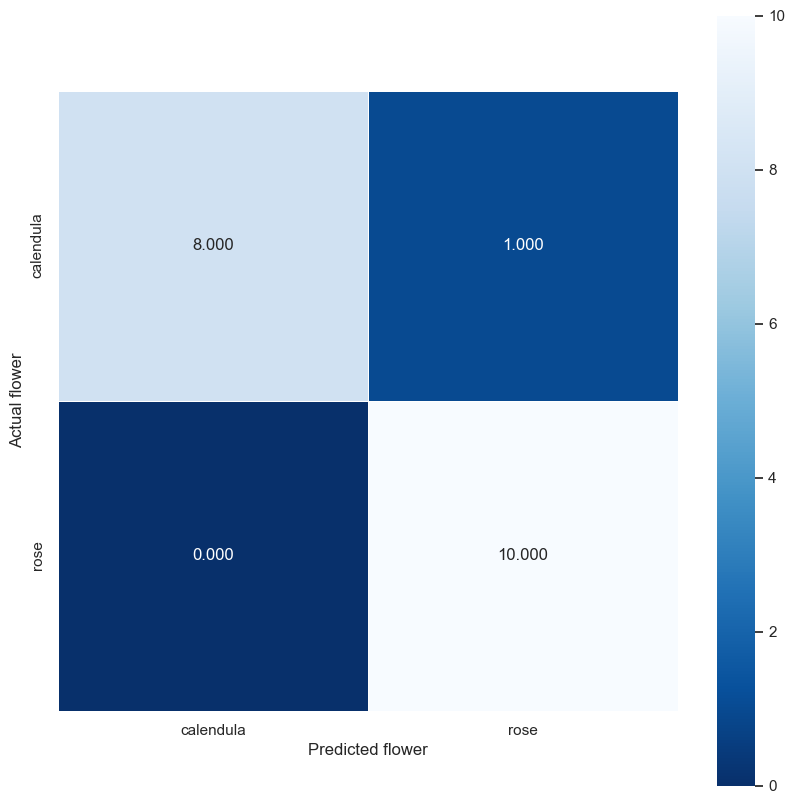

In [29]:
# Same confusion matrix format: rows show actual labels, columns show predictions
labels = ['calendula', 'rose']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(outcome_data['name'], y_pred_testset, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual flower');
plt.xlabel('Predicted flower');

While we made one small error, the final result is excellent! Our model successfully learned to distinguish between these two flower types from just their average color values. 🌹

## 10.7 Chapter Summary

### The Main Idea

In this chapter, we learned how to apply Machine Learning to image data, which is fundamentally different from the tabular data we've worked with before. The key challenge is: **how do you convert raw image data into numbers that a machine learning model can understand?**

### The Problem: Images are Big

Each flower image is 128 × 128 pixels with 4 color channels (RGBA). That's 65,536 numbers per image! If we tried to feed all these raw values into our model, we'd have two problems:

- **Too much data**: Our model would struggle to learn from so many features
- **Too much memory**: We couldn't even load all the images efficiently

### The Solution: Dimensionality Reduction

We solved this using a clever technique called **dimensionality reduction**. Instead of keeping all 65,536 pixel values, we reduced each image to just 3 numbers: the **mean** (average) of each color channel.

#### How the mean helped:

1. **Captures the essence**: The average red, green, and blue values tell us the overall "color tone" of each flower. Calendulas are typically warmer colors, while roses may have different color profiles.

2. **Massive simplification**: We went from 65,536 values per image down to 3 values. This is like taking a detailed photo and creating a simple color summary instead.

3. **Computation**: Our Random Forest model could now learn quickly with manageable data, avoiding the "curse of dimensionality."

4. **Still effective**: Despite this huge simplification, our model achieved excellent accuracy on the test set, showing that the mean values captured enough information to distinguish between flower types.

### The Workflow We Followed

1. **Load and explore**: Read image files and understood their structure (3D arrays of pixel values)
2. **Transform**: Extract color channel information and compute the mean for each channel
3. **Label**: Merge our transformed data with flower labels from a CSV file
4. **Train**: Use a Random Forest classifier to learn patterns from the color means
5. **Evaluate**: Test the model on unseen flowers to verify it actually learned, not just memorized

### Key Takeaway

**Data engineering is just as important as model building.** Before you can train any machine learning model, you often need to transform raw data into a format that's both manageable and meaningful. By choosing the right reduction technique (the mean), we created a simplified but effective representation that allowed our model to succeed. 🌹📊